# 15-minute LSTM training 

Trains Single / Double / BiLSTM on clean preprocessed 15min data.


In [1]:
window_sizes = [1, 4, 8, 16, 24, 48, 64, 96, 672]
epochs = 50
test_ratio = 0.18

from google.colab import drive
drive.mount("/content/drive")
BASE = "/content/drive/MyDrive/Shared-Colab-Storage/research"

DATA_CSV = f"{BASE}/outputs/preprocess/15min/data.csv"
SCALER_PKL = f"{BASE}/outputs/preprocess/15min/scaler.pkl"
SAVE_PATH = f"{BASE}/outputs/train/15min"
TUNING_JSON = f"{BASE}/outputs/train/15min/tuning/best_hparams.json"



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install -q pandas numpy scikit-learn matplotlib tensorflow

import os
import pickle
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import backend as K
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

def rmse(y_true, y_pred):
    return K.sqrt(K.mean(K.square(y_true - y_pred)))

os.makedirs(SAVE_PATH, exist_ok=True)

## Load preprocessed 15min data

In [3]:
scaled_df = pd.read_csv(DATA_CSV)
with open(SCALER_PKL, "rb") as f:
    scaler = pickle.load(f)

feature_cols = list(scaled_df.columns)
target_idx = 0
n_features = len(feature_cols)

print("Rows:", len(scaled_df))
print("Features:", feature_cols)
scaled_df.head()

Rows: 35040
Features: ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'WeekStatus', 'Day_of_week', 'Load_Type', 'hour_sin', 'hour_cos']


,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Lagging_Current_Power_Factor,Leading_Current_Power_Factor,WeekStatus,Day_of_week,Load_Type,hour_sin,hour_cos
0,0.006437,0.035703,0.529020,1.0,0.0,0.166667,0.0,0.500000,1.000000
1,0.004778,0.030441,0.575167,1.0,0.0,0.166667,0.0,0.532702,0.998929
2,0.010286,0.046022,0.473042,1.0,0.0,0.166667,0.0,0.565263,0.995722
3,0.005243,0.033846,0.528703,1.0,0.0,0.166667,0.0,0.597545,0.990393
4,0.005707,0.036735,0.493974,1.0,0.0,0.166667,0.0,0.629410,0.982963


## 2) Sliding windows

In [4]:
arr = scaled_df[feature_cols].to_numpy(dtype=np.float32)

data = {}
for window in window_sizes:
    X, y = [], []
    for i in range(len(arr) - window):
        X.append(arr[i:i + window])
        y.append(arr[i + window, target_idx])
    X, y = np.array(X), np.array(y)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_ratio, shuffle=False
    )
    data[f"win{window}"] = dict(
        X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test
    )
    print(f"win{window}: train {X_train.shape}, test {X_test.shape}")

win1: train (28731, 1, 9), test (6308, 1, 9)
win4: train (28729, 4, 9), test (6307, 4, 9)
win8: train (28726, 8, 9), test (6306, 8, 9)
win16: train (28719, 16, 9), test (6305, 16, 9)
win24: train (28713, 24, 9), test (6303, 24, 9)
win48: train (28693, 48, 9), test (6299, 48, 9)
win64: train (28680, 64, 9), test (6296, 64, 9)
win96: train (28654, 96, 9), test (6290, 96, 9)
win672: train (28181, 672, 9), test (6187, 672, 9)


In [5]:
def build_model(stack, window, units, dropout):
    model = Sequential()
    if stack == "single":
        model.add(LSTM(units, input_shape=(window, n_features)))
    elif stack == "double":
        model.add(LSTM(units, return_sequences=True, input_shape=(window, n_features)))
        model.add(LSTM(units))
    else:
        model.add(Bidirectional(LSTM(units), input_shape=(window, n_features)))
    model.add(Dropout(dropout))
    model.add(Dense(1))
    return model



In [6]:
TUNE_WINDOW = 24
TUNE_STACK = "single"
VAL_RATIO = 0.15           
MAX_EPOCHS = 50
param_grid = {
    "batch_size": [32, 48,  64],
    "learning_rate": [1e-3, 5e-4, 1e-4],
    "units": [64,96, 128],
    "dropout": [0.1, 0.2, 0.3],
}  
os.makedirs(os.path.dirname(TUNING_JSON), exist_ok=True)
if False:
    w = TUNE_WINDOW
    X, y = [], []
    for i in range(len(arr) - w):
        X.append(arr[i:i + w])
        y.append(arr[i + w, target_idx])
    X, y = np.array(X), np.array(y)
    n = len(X)
    n_test = int(n * test_ratio)
    n_val = int((n - n_test) * VAL_RATIO)
    X_train = X[: n - n_test - n_val]
    y_train = y[: n - n_test - n_val]
    X_val   = X[n - n_test - n_val : n - n_test]
    y_val   = y[n - n_test - n_val : n - n_test]
    tune_early = EarlyStopping(
        monitor="val_loss", patience=7,
        restore_best_weights=True, verbose=0,
    )
    results = []
    for combo in itertools.product(*param_grid.values()):
        params = dict(zip(param_grid.keys(), combo))
        print("trying:", params)
        K.clear_session()
        model = build_model(TUNE_STACK, w, params["units"], params["dropout"])
        model.compile(
            optimizer=Adam(learning_rate=params["learning_rate"]),
            loss=rmse, metrics=["mae"],
        )
        hist = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=MAX_EPOCHS,
            batch_size=params["batch_size"],
            callbacks=[tune_early],
            verbose=0,
        )
        best_val = float(min(hist.history["val_loss"]))
        results.append({**params, "val_rmse_scaled": best_val})
    results_df = pd.DataFrame(results).sort_values("val_rmse_scaled")
    print("\nTop 5:")
    print(results_df.head().to_string(index=False))
    best_row = results_df.iloc[0]
    best_hp = {
        "batch_size": int(best_row["batch_size"]),
        "learning_rate": float(best_row["learning_rate"]),
        "units": int(best_row["units"]),
        "dropout": float(best_row["dropout"]),
        "epochs": MAX_EPOCHS,
        "patience": 7,
        "tuned_on": f"{TUNE_STACK}_win{TUNE_WINDOW}",
    }
    with open(TUNING_JSON, "w") as f:
        json.dump(best_hp, f, indent=2)
    print("\nSaved:", TUNING_JSON)
    print(best_hp)
else:
    if os.path.exists(TUNING_JSON):
        print("Tuning skipped, existing hparams loaded")
    else:
        print("No tuning file yet — next cell uses defaults.")

Tuning skipped, existing hparams loaded


In [7]:
hp = {
    "batch_size": 32,
    "learning_rate": 1e-3,
    "units": 64,
    "dropout": 0.1,
    "epochs": 50,
    "patience": 7,
}
if os.path.exists(TUNING_JSON):
    with open(TUNING_JSON) as f:
        hp.update(json.load(f))

epochs = hp["epochs"]
batch_size = hp["batch_size"]
learning_rate = hp["learning_rate"]
lstm_units = hp["units"]
dropout_rate = hp["dropout"]
patience = hp["patience"]
val_ratio = 0.15  

## 3) Train models

In [8]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=patience,
    restore_best_weights=True,
    verbose=1,
)

In [9]:
stacks = ["single", "double", "bidir"]
trained = {}

for stack in stacks:
    print(f"\n========== {stack.upper()} LSTM ==========")
    model_dir = os.path.join(SAVE_PATH, stack, "models")
    hist_dir = os.path.join(SAVE_PATH, stack, "history")
    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(hist_dir, exist_ok=True)
    trained[stack] = {}

    for window in window_sizes:
        model_path = os.path.join(model_dir, f"win{window}.keras")
        hist_path = os.path.join(hist_dir, f"win{window}.pkl")
        d = data[f"win{window}"]

        if os.path.exists(model_path):
            model = load_model(model_path, custom_objects={"rmse": rmse})
            hist = pickle.load(open(hist_path, "rb")) if os.path.exists(hist_path) else {}
            print(f"  win{window}: loaded")
            trained[stack][window] = {"model": model, "history": hist}
            continue

        print(f"  win{window}: training...")
        model = build_model(stack, window, lstm_units, dropout_rate)
        model.compile(
            optimizer=Adam(learning_rate=learning_rate),
            loss=rmse,
            metrics=["mae"],
        )

        hist = model.fit(
            d["X_train"], d["y_train"],
            validation_split=val_ratio,    
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stop],
            verbose=1,
        )
        model.save(model_path)
        pickle.dump(hist.history, open(hist_path, "wb"))
        trained[stack][window] = {"model": model, "history": hist.history}
        print(f"  win{window}: saved")


========== SINGLE LSTM ==========
  win1: loaded
  win4: loaded
  win8: loaded
  win16: loaded
  win24: loaded
  win48: loaded
  win64: loaded
  win96: loaded
  win672: loaded

========== DOUBLE LSTM ==========
  win1: loaded
  win4: loaded
  win8: loaded
  win16: loaded
  win24: loaded
  win48: loaded
  win64: loaded
  win96: loaded
  win672: loaded

========== BIDIR LSTM ==========
  win1: loaded
  win4: loaded
  win8: loaded
  win16: loaded
  win24: loaded
  win48: loaded
  win64: loaded
  win96: loaded
  win672: loaded


## 4) Evaluate

In [10]:
def to_kwh(values):
    values = np.asarray(values).ravel()
    d = np.zeros((len(values), n_features))
    d[:, target_idx] = values
    return scaler.inverse_transform(d)[:, target_idx]

rows = []
for stack in stacks:
    for window in window_sizes:
        if window not in trained[stack]:
            continue
        model = trained[stack][window]["model"]
        y_test = data[f"win{window}"]["y_test"]
        y_pred = model.predict(data[f"win{window}"]["X_test"], verbose=0).ravel()

        yt, yp = to_kwh(y_test), to_kwh(y_pred)
        rmse_k = float(np.sqrt(mean_squared_error(yt, yp)))
        mae_k = float(mean_absolute_error(yt, yp))
        r2_k = float(r2_score(yt, yp))
        mean_obs = np.mean(yt)
        wia_k = float(1 - np.sum((yp - yt) ** 2) / np.sum((np.abs(yp - mean_obs) + np.abs(yt - mean_obs)) ** 2))

        rows.append({
            "model": stack, "window": window,
            "rmse_kwh": rmse_k, "mae_kwh": mae_k, "r2": r2_k, "wia": wia_k,
        })

metrics_df = pd.DataFrame(rows)
metrics_df.to_csv(os.path.join(SAVE_PATH, "results_metrics.csv"), index=False)

best = metrics_df.loc[metrics_df["rmse_kwh"].idxmin()]
print("Best model:")
print(best)
metrics_df.sort_values("rmse_kwh").head(10)

Best model:
model         single
window            16
rmse_kwh    8.328125
mae_kwh     4.140053
r2          0.929784
wia         0.981348
Name: 3, dtype: object


,model,window,rmse_kwh,mae_kwh,r2,wia
3,single,16,8.328125,4.140053,0.929784,0.981348
7,single,96,8.330166,4.444386,0.929852,0.981528
22,bidir,24,8.392687,4.480694,0.928702,0.981762
6,single,64,8.406476,4.267126,0.928517,0.981082
13,double,24,8.437484,4.575734,0.927939,0.981007
25,bidir,96,8.483078,4.997174,0.927253,0.979781
26,bidir,672,8.492433,4.497492,0.927735,0.981010
16,double,96,8.510516,4.335125,0.926782,0.980934
15,double,64,8.517514,4.362206,0.926616,0.980845
2,single,8,8.555015,4.510562,0.925899,0.980818


## 5) RMSE heatmap

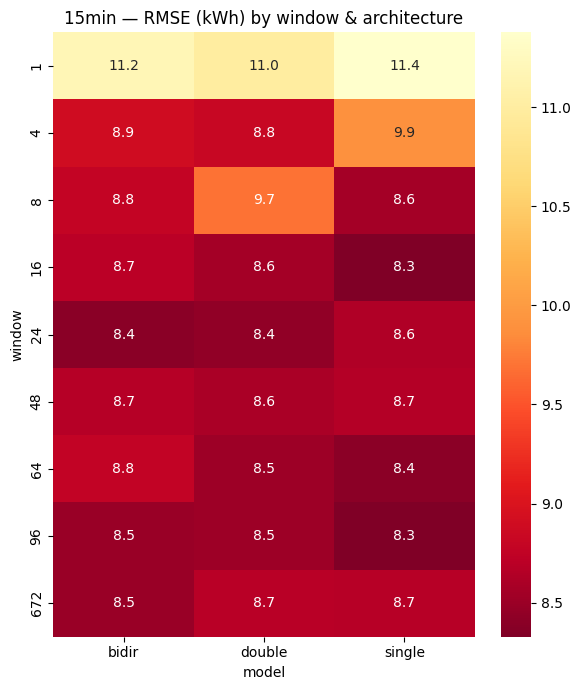

In [11]:
pivot = metrics_df.pivot(index="window", columns="model", values="rmse_kwh")
plt.figure(figsize=(6, 7))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd_r")
plt.title("15min — RMSE (kWh) by window & architecture")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, "rmse_heatmap.png"), dpi=120)
plt.show()

## Done

Saved under `outputs/train/15min/`:
- models, `results_metrics.csv`, `rmse_heatmap.png`